# Exploratory Data Analysis — Covariation

This notebook covers **covariation**: how two or more variables vary together.
Variation within single variables is in `05_eda_variation.ipynb`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # https://seaborn.pydata.org/
import statsmodels.formula.api as smf  # https://www.statsmodels.org/

sns.set_theme()

MPG_URL = "https://vincentarelbundock.github.io/Rdatasets/csv/ggplot2/mpg.csv"

diamonds = sns.load_dataset("diamonds")
mpg = pd.read_csv(MPG_URL).drop(columns="rownames")
smaller = diamonds[diamonds["carat"] < 3]


## Covariation

If variation is behavior **within** a variable, covariation is behavior **between** variables.

**Covariation** means values of two or more variables tend to change together.
Visualize relationships between variables to spot it.


### A categorical and a numerical variable

How does diamond `price` vary with `cut`?


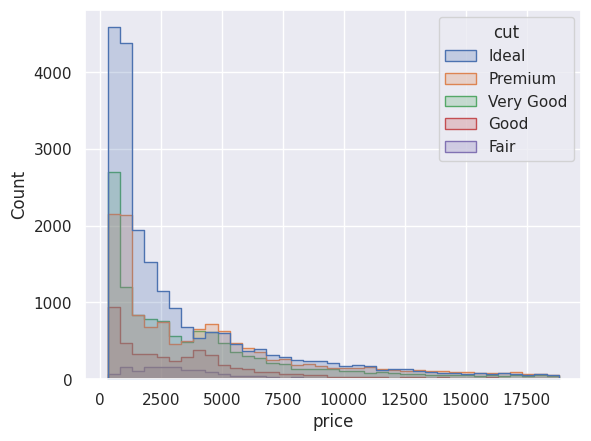

In [2]:
ax = sns.histplot(
    data=diamonds,
    x="price",
    hue="cut",
    binwidth=500,
    element="step",
    common_norm=False,
)


Counts differ so much by `cut` that shapes are hard to compare. Use **density** instead:


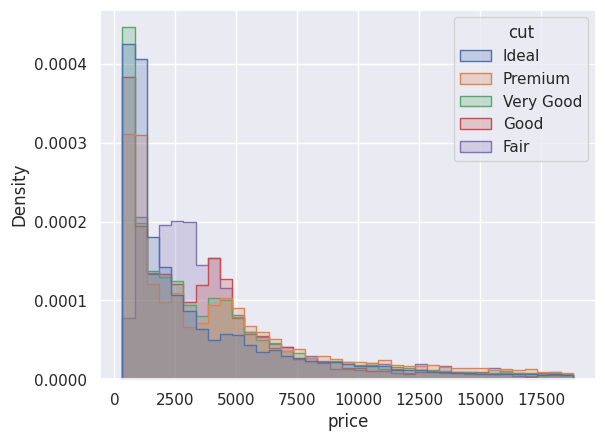

In [3]:
ax = sns.histplot(
    data=diamonds,
    x="price",
    hue="cut",
    binwidth=500,
    stat="density",
    element="step",
    common_norm=False,
)


Fair diamonds appear to have the highest average price — surprising for the lowest quality.
A simpler view is side-by-side boxplots:


<Axes: xlabel='cut', ylabel='price'>

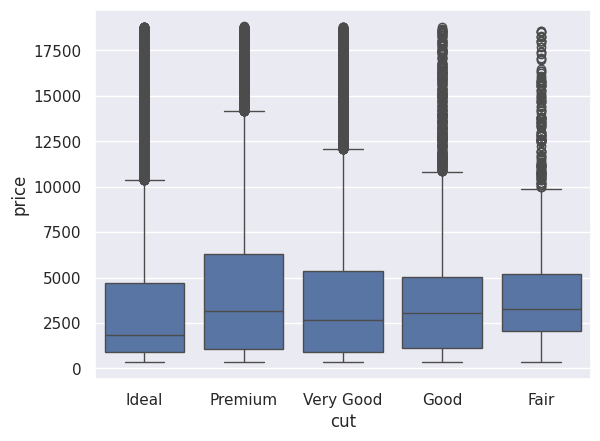

In [4]:
sns.boxplot(data=diamonds, x="cut", y="price")


Boxplots are compact but show less detail.
They support the finding that better cuts are often **cheaper** at a given size — exercises explore why.

Many categories lack a natural order.
Reorder by a summary statistic to reveal trends.
Example: highway mileage (`hwy`) by vehicle `class` in ggplot2's `mpg` dataset.


<Axes: xlabel='class', ylabel='hwy'>

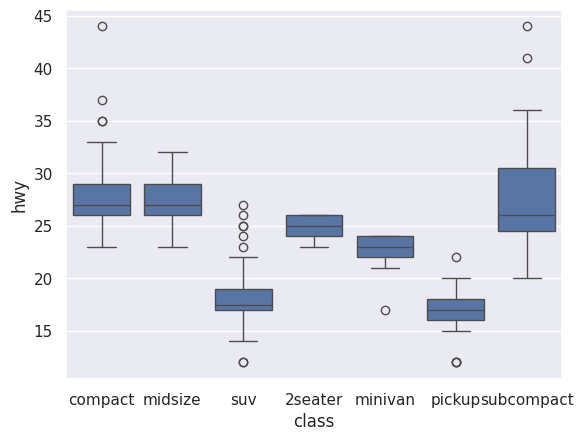

In [5]:
sns.boxplot(data=mpg, x="class", y="hwy")


<Axes: xlabel='class', ylabel='hwy'>

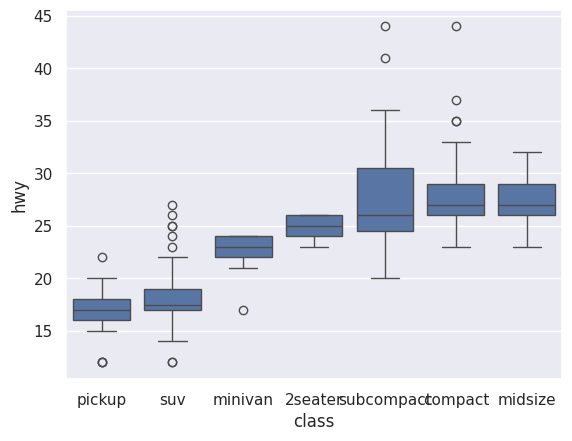

In [6]:
class_order = (
    mpg.groupby('class', observed=True)['hwy']
    .median()
    .sort_values()
    .index
)

sns.boxplot(
    data=mpg,
    x="class",
    y="hwy",
    order=class_order,
)


Long category names read better on the y-axis:


<Axes: xlabel='hwy', ylabel='class'>

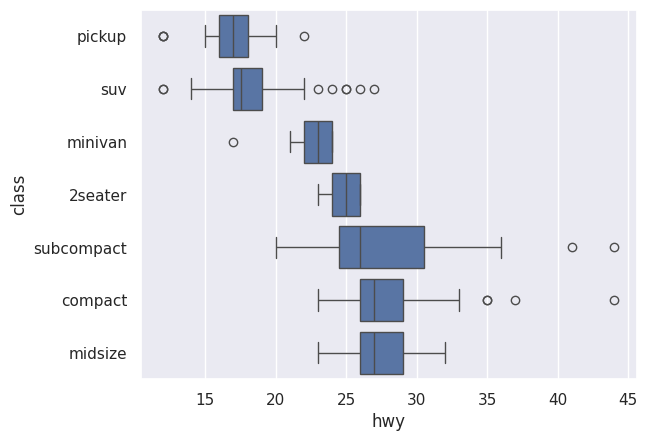

In [7]:
sns.boxplot(
    data=mpg,
    x="hwy",
    y="class",
    order=class_order,
)


### Two categorical variables

Count combinations of `color` and `cut`:


In [8]:
print(diamonds.groupby(['color', 'cut'], observed=True).size().reset_index(name='n').head(10))


  color        cut     n
0     D      Ideal  2834
1     D    Premium  1603
2     D  Very Good  1513
3     D       Good   662
4     D       Fair   163
5     E      Ideal  3903
6     E    Premium  2337
7     E  Very Good  2400
8     E       Good   933
9     E       Fair   224


A heatmap makes the joint distribution easy to scan:


Text(46.25, 0.5, 'color')

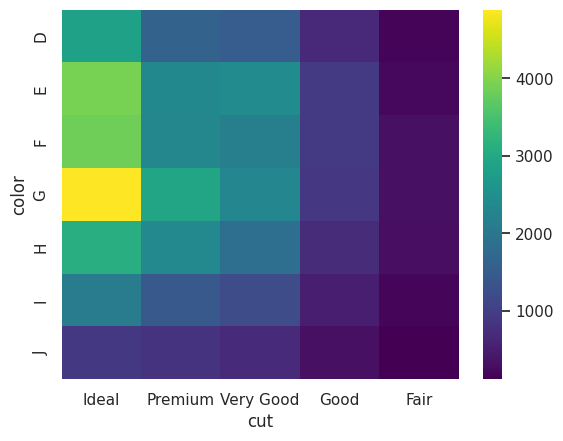

In [9]:
color_cut = pd.crosstab(diamonds['color'], diamonds['cut'])

ax = sns.heatmap(
    color_cut,
    annot=False,
    cmap="viridis",
)
ax.set_xlabel('cut')
ax.set_ylabel('color')


### Two numerical variables

Scatterplots show covariation as a pattern in the points.


<Axes: xlabel='carat', ylabel='price'>

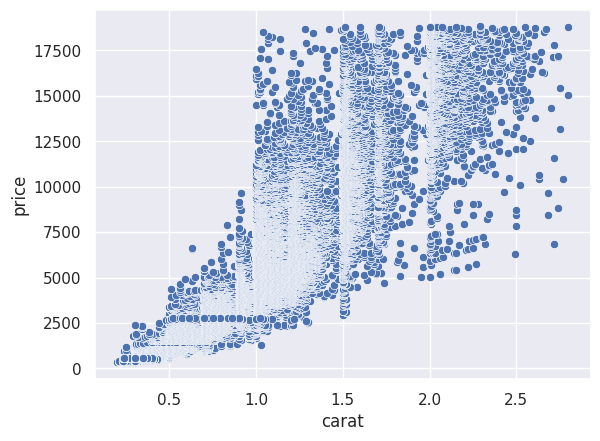

In [10]:
sns.scatterplot(data=smaller, x="carat", y="price")


Large samples overplot. Lower `alpha` so dense regions show through:


<Axes: xlabel='carat', ylabel='price'>

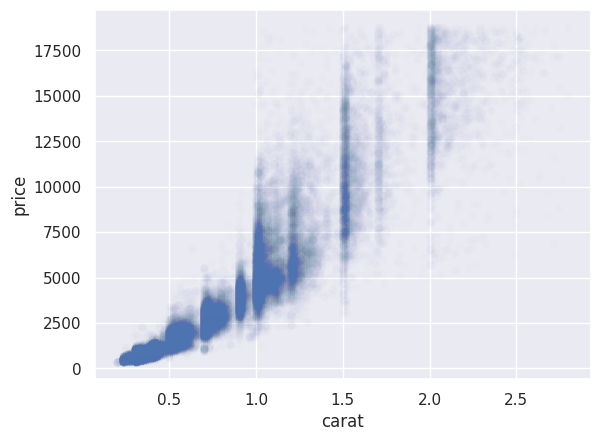

In [11]:
sns.scatterplot(
    data=smaller,
    x="carat",
    y="price",
    alpha=0.01,
)


For very large data, bin in two dimensions:


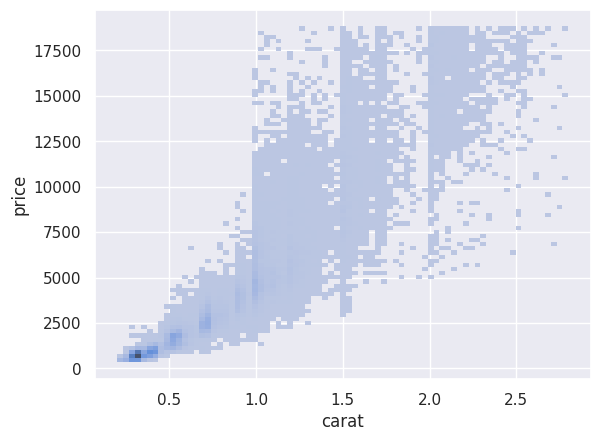

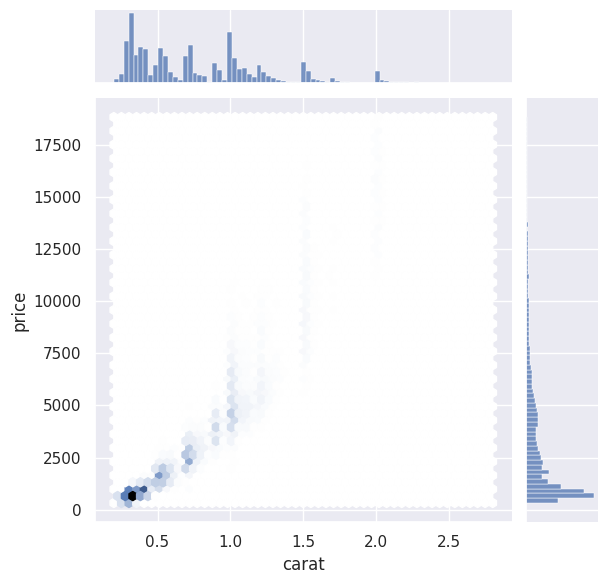

In [12]:
sns.histplot(data=smaller, x="carat", y="price")
plt.show()

sns.jointplot(
    data=smaller,
    x="carat",
    y="price",
    kind="hex",
)


Or bin `carat` and use boxplots of `price` within each bin:


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27],
 [Text(0, 0, '(0.0, 0.1]'),
  Text(1, 0, '(0.1, 0.2]'),
  Text(2, 0, '(0.2, 0.3]'),
  Text(3, 0, '(0.3, 0.4]'),
  Text(4, 0, '(0.4, 0.5]'),
  Text(5, 0, '(0.5, 0.6]'),
  Text(6, 0, '(0.6, 0.7]'),
  Text(7, 0, '(0.7, 0.8]'),
  Text(8, 0, '(0.8, 0.9]'),
  Text(9, 0, '(0.9, 1.0]'),
  Text(10, 0, '(1.0, 1.1]'),
  Text(11, 0, '(1.1, 1.2]'),
  Text(12, 0, '(1.2, 1.3]'),
  Text(13, 0, '(1.3, 1.4]'),
  Text(14, 0, '(1.4, 1.5]'),
  Text(15, 0, '(1.5, 1.6]'),
  Text(16, 0, '(1.6, 1.7]'),
  Text(17, 0, '(1.7, 1.8]'),
  Text(18, 0, '(1.8, 1.9]'),
  Text(19, 0, '(1.9, 2.0]'),
  Text(20, 0, '(2.0, 2.1]'),
  Text(21, 0, '(2.1, 2.2]'),
  Text(22, 0, '(2.2, 2.3]'),
  Text(23, 0, '(2.3, 2.4]'),
  Text(24, 0, '(2.4, 2.5]'),
  Text(25, 0, '(2.5, 2.6]'),
  Text(26, 0, '(2.6, 2.7]'),
  Text(27, 0, '(2.7, 2.8]')])

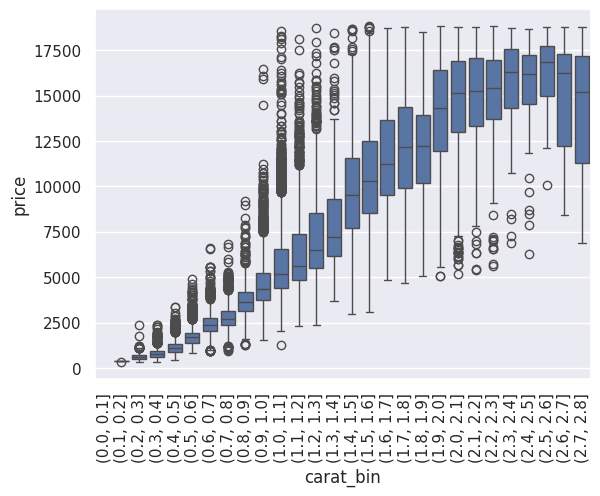

In [13]:
smaller = smaller.copy()
smaller['carat_bin'] = pd.cut(
    smaller['carat'],
    bins=np.arange(0, smaller['carat'].max() + 0.1, 0.1),
)

sns.boxplot(
    data=smaller,
    x="carat_bin",
    y="price",
)
plt.xticks(rotation=90)


## Patterns and models

If a systematic relationship exists, it appears as a pattern.
Ask whether it could be coincidence, how strong it is, and what other variables matter.

Models extract patterns.
Cut vs. price is hard to read because cut, carat, and price are intertwined.
Fit log(price) ~ log(carat), take residuals, and exponentiate them to return to dollar scale.


In [14]:
diamonds_model = diamonds.copy()
diamonds_model['log_price'] = np.log(diamonds_model['price'])
diamonds_model['log_carat'] = np.log(diamonds_model['carat'])

fit = smf.ols('log_price ~ log_carat', data=diamonds_model).fit()
diamonds_model['resid'] = np.exp(diamonds_model['log_price'] - fit.fittedvalues)


<Axes: xlabel='carat', ylabel='resid'>

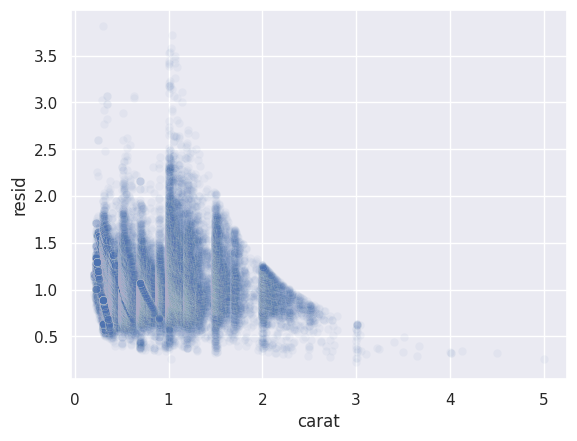

In [15]:
sns.scatterplot(data=diamonds_model, x="carat", y="resid", alpha=0.05)


After removing the carat effect, better cuts tend to have higher residuals (price relative to size):


<Axes: xlabel='cut', ylabel='resid'>

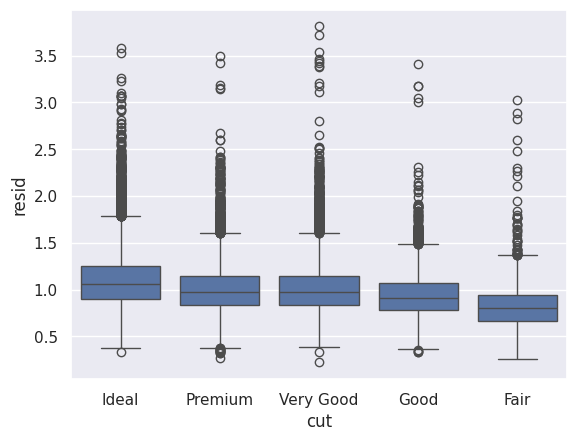

In [16]:
sns.boxplot(data=diamonds_model, x="cut", y="resid")


## Summary

You now have tools for:

- Variation within one variable (histograms, outliers, missing values).
- Covariation between two variables (overlaid distributions, heatmaps, scatterplots, bins).
- A first look at models that peel away strong relationships to reveal subtler ones.

**Practice:** `exset_1/02_covariation_exercises.ipynb`.
